In [12]:
#if (!require("BiocManager", quietly = TRUE))
    #install.packages("BiocManager")

#BiocManager::install("MPRAnalyze")
#Format the data into MPRA project
library("MPRAnalyze")
library("BiocParallel")
library("parallel")
dropEnhancer <- function(df_RNA){
    row.names(df_RNA) <-df_RNA$enhancer_id	
    df <- df_RNA[ , !(names(df_RNA) %in% c("enhancer_id"))]
    return(df)
    }

dropX <- function(df_RNA){
    row.names(df_RNA) <-df_RNA$X
    df <- df_RNA[ , !(names(df_RNA) %in% c("X"))]
    return(df)
    }

num_cores <- 24
register(MulticoreParam(num_cores))
bpparam <- MulticoreParam(num_cores, log = TRUE, stop.on.error = FALSE)


Load experiment

# All Brain

In [22]:
df_DNA <- read.csv("/Volumes/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_pool_control.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_reshaped_altref_control.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/mpra3_lib_analysis/annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('/Volumes/T7/mpra3_lib_analysis/indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"/Volumes/T7/mpra3_lib_analysis/20260714_MAD_BrainR1R2merged20260121_control_R1R2.csv")


Fitting model...

############### LOG OUTPUT ###############
Task: 1
Node: 24
Timestamp: 2026-07-14 14:11:51.302474
Success: TRUE

Task duration:
   user  system elapsed 
  0.091   0.044   0.219 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6255239 334.1   11606267 619.9         NA 10675701 570.2
Vcells 11203433  85.5   18705754 142.8      32768 18705489 142.8

Log messages:
INFO [2026-07-14 14:11:50] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 2
Node: 23
Timestamp: 2026-07-14 14:11:51.872977
Success: TRUE

Task duration:
   user  system elapsed 
  0.080   0.036   0.145 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6255232 334.1   11606267 619.9         NA 10675701 570.2
Vcells 11203432  85.5   18705754 142.8      32768 18705489 142.8

Log messages:
INFO [2026-07-14 14:11:50] loading futile.logger package

stderr and stdout:


############### LOG 

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_Brain.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 2
Node: 23
Timestamp: 2024-11-26 23:51:17.814263
Success: TRUE

Task duration:
   user  system elapsed 
  4.477   0.322   5.195 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6182068 330.2   11623467 620.8 10290760 549.6
Vcells 11239709  85.8   19179330 146.4 19178645 146.4

Log messages:
INFO [2024-11-26 23:51:12] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 21
Node: 4
Timestamp: 2024-11-26 23:51:18.666053
Success: TRUE

Task duration:
   user  system elapsed 
  4.356   0.394   5.327 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6196156 331.0   11623467 620.8 10290760 549.6
Vcells 11317766  86.4   19179330 146.4 19178645 146.4

Log messages:
INFO [2024-11-26 23:51:13] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 1
Node: 24
Timestamp: 2024-11-26 23:5

In [ ]:
#Brain with control without SV40
df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_pool_withcontrol_noSV40.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260121_MAD_Brain.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 2
Node: 23
Timestamp: 2026-01-23 19:43:31.191967
Success: TRUE

Task duration:
   user  system elapsed 
  2.416   0.146   2.568 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6293991 336.2   11957055 638.6 10095298 539.2
Vcells 11321918  86.4   18664808 142.5 16782790 128.1

Log messages:
INFO [2026-01-23 19:43:28] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2026-01-23 19:43:31.859229
Success: TRUE

Task duration:
   user  system elapsed 
  2.205   0.304   2.531 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6300169 336.5   11957055 638.6 10095298 539.2
Vcells 11353315  86.7   18664808 142.5 16782790 128.1

Log messages:
INFO [2026-01-23 19:43:29] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 9
Node: 16
Timestamp: 2026-01-23 19:4

In [ ]:
#Brain with control
df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_pool_withcontrol.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_reshaped_altref_withcontrol.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260121_MAD_Brain.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2026-01-24 19:18:01.303758
Success: TRUE

Task duration:
   user  system elapsed 
  1.506   0.207   1.713 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6304999 336.8   12039294 643.0 12039294 643.0
Vcells 11407005  87.1   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-24 19:17:59] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 2
Node: 23
Timestamp: 2026-01-24 19:18:01.887705
Success: TRUE

Task duration:
   user  system elapsed 
  1.997   0.206   2.203 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6309820 337.0   12039294 643.0 12039294 643.0
Vcells 11433862  87.3   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-24 19:17:59] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 3
Node: 22
Timestamp: 2026-01-24 19:1

# Brain Region With Baseline

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  ) 
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ Animal+Tissue
                            )
alpha <- getAlpha(obj, by.factor = "Tissue")
for (col_names in names(alpha)){   
    result <- testEmpirical(obj = obj,statistic = alpha[,col_names])
    row.names(result)<-row.names(alpha)
    write.csv(result, paste("enhancer_activities/MAD_OneTail_NoControl/20241126_MAD_",col_names,".csv",sep=""))}

Fitting model...

############### LOG OUTPUT ###############
Task: 6
Node: 19
Timestamp: 2024-11-26 23:56:59.03547
Success: TRUE

Task duration:
   user  system elapsed 
 11.559   0.431  12.170 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6182779 330.2   11623467 620.8 10290760 549.6
Vcells 11243610  85.8   23095196 176.3 23094931 176.3

Log messages:
INFO [2024-11-26 23:56:46] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 13
Node: 12
Timestamp: 2024-11-26 23:57:00.036205
Success: TRUE

Task duration:
   user  system elapsed 
 11.514   0.494  12.591 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6193497 330.8   11623467 620.8 10290760 549.6
Vcells 11309302  86.3   23095196 176.3 23094931 176.3

Log messages:
INFO [2024-11-26 23:56:47] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 14
Node: 11
Timestamp: 2024-11-26 23:

# THP1 Macrophage All

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Macrophage_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
annot_DNA

,Tissue,Delivery,Date,Animal,Test,Function,Parent,IFNB,IFNG,LPSIFNG,⋯,Barcode_Allele,Allele_String,Test_Allele,Animal_Allele,Tissue_Allele,Allele,IFNB_interaction,IFNG_interaction,LPSIFNG_interaction,Naive_interaction
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
IFNB_THP1mac_ZC58_R_ALT_Barcode_1,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,1_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_2,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,2_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_3,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,3_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_4,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,4_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_5,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,5_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_6,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,6_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_7,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,7_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_8,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,8_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0
IFNB_THP1mac_ZC58_R_ALT_Barcode_9,THP1_IFNB,Nucleofector,NA,Macrophage,IFNB_THP1mac_ZC58_R,Immune,THP1_Macrophage,1,0,0,⋯,9_ALT,ALT,IFNB_THP1mac_ZC58_R_ALT,Macrophage_ALT,THP1_IFNB_ALT,1,1,0,0,0


In [ ]:
df_DNA <- read.csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Macrophage_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_THP1Macrophage.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-11-26 23:53:58.833601
Success: TRUE

Task duration:
   user  system elapsed 
128.798   1.222 136.082 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6182684 330.2   11623467 620.8 10290760 549.6
Vcells 12210360  93.2   23095196 176.3 19179330 146.4

Log messages:
INFO [2024-11-26 23:51:42] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 19
Node: 6
Timestamp: 2024-11-26 23:54:09.33334
Success: TRUE

Task duration:
   user  system elapsed 
140.227   0.780 146.762 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6183369 330.3   11623467 620.8 10290760 549.6
Vcells 12218802  93.3   23095196 176.3 19179330 146.4

Log messages:
INFO [2024-11-26 23:51:42] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 12
Node: 13
Timestamp: 2024-11-26 23:5

# THP1 Macrophage with Baseline

In [ ]:

#############################################################################################################################################

df_DNA <- read.csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Macrophage_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ Tissue
                            )

alpha <- getAlpha(obj, by.factor = "Tissue")
for (col_names in names(alpha)){   
    result <- testEmpirical(obj = obj,statistic = alpha[,col_names])
    row.names(result)<-row.names(alpha)
    write.csv(result, paste("enhancer_activities/MAD_OneTail_NoControl/20240824_MAD_",col_names,".csv",sep=""))}

In [ ]:
colnames(df_DNA)

[1] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_1" 
  [2] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_2" 
  [3] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_3" 
  [4] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_4" 
  [5] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_5" 
  [6] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_6" 
  [7] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_7" 
  [8] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_8" 
  [9] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_9" 
 [10] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_10"
 [11] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_11"
 [12] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_12"
 [13] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_13"
 [14] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_14"
 [15] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_15"
 [16] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_1" 
 [17] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_2" 
 [18] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_3" 
 [19] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_4" 
 [20] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_5" 
 [21] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_6" 
 [22] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_7" 
 [23] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_8" 
 [24] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_9" 
 [25] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_10"
 [26] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_11"
 [27] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_12"
 [28] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_13"
 [29] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_14"
 [30] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_15"
 [31] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_1" 
 [32] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_2" 
 [33] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_3" 
 [34] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_4" 
 [35] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_5" 
 [36] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_6" 
 [37] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_7" 
 [38] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_8" 
 [39] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_9" 
 [40] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_10"
 [41] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_11"
 [42] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_12"
 [43] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_13"
 [44] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_14"
 [45] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_15"
 [46] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_1"  
 [47] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_2"  
 [48] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_3"  
 [49] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_4"  
 [50] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_5"  
 [51] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_6"  
 [52] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_7"  
 [53] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_8"  
 [54] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_9"  
 [55] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_10" 
 [56] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_11" 
 [57] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_12" 
 [58] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_13" 
 [59] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_14" 
 [60] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_15" 
 [61] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_1"  
 [62] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_2"  
 [63] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_3"  
 [64] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_4"  
 [65] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_5"  
 [66] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_6"  
 [67] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_7"  
 [68] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_8"  
 [69] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_9"  
 [70] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_10" 
 [71] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_11" 
 [72] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_12" 
 [73] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_13" 
 [74] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_14" 
 [75] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_15" 
 [76] "Naive_THP1mac_ZC55_R_ALT_Barcode_1"    
 [77] "Naive_THP1mac_ZC55_R_ALT_Barcode_2"    
 [78] "Naive_THP1mac_ZC55_R_ALT_Barcode_3"    
 [79] "Naive_THP1mac_ZC55_R_ALT_Barcode_4"    
 [80] "Naive_THP1mac_ZC55_R_ALT_Barcode_5"    
 [81] "Naive_THP1mac_ZC55_R_ALT_Barcode_6"    
 [82] "Naive_THP1mac_ZC55_R_ALT_Barcode_7"    
 [83] "Naive_THP1mac_ZC55_R_ALT_Barcode_8"    
 [84] "Naive_THP1mac_ZC55_R_ALT_Barcode_9"    
 [85] "Naive_THP1mac_ZC55_R_ALT_Barcode_10"   
 [86] "

In [ ]:
rownames(annot_DNA)

[1] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_1" 
  [2] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_2" 
  [3] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_3" 
  [4] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_4" 
  [5] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_5" 
  [6] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_6" 
  [7] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_7" 
  [8] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_8" 
  [9] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_9" 
 [10] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_10"
 [11] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_11"
 [12] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_12"
 [13] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_13"
 [14] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_14"
 [15] "LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_15"
 [16] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_1" 
 [17] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_2" 
 [18] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_3" 
 [19] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_4" 
 [20] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_5" 
 [21] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_6" 
 [22] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_7" 
 [23] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_8" 
 [24] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_9" 
 [25] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_10"
 [26] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_11"
 [27] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_12"
 [28] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_13"
 [29] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_14"
 [30] "LPSIFNG_THP1mac_ZC115_R_ALT_Barcode_15"
 [31] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_1" 
 [32] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_2" 
 [33] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_3" 
 [34] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_4" 
 [35] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_5" 
 [36] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_6" 
 [37] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_7" 
 [38] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_8" 
 [39] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_9" 
 [40] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_10"
 [41] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_11"
 [42] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_12"
 [43] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_13"
 [44] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_14"
 [45] "LPSIFNG_THP1mac_ZC125_R_ALT_Barcode_15"
 [46] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_1"  
 [47] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_2"  
 [48] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_3"  
 [49] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_4"  
 [50] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_5"  
 [51] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_6"  
 [52] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_7"  
 [53] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_8"  
 [54] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_9"  
 [55] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_10" 
 [56] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_11" 
 [57] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_12" 
 [58] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_13" 
 [59] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_14" 
 [60] "LPSIFNG_THP1mac_ZC89_R_ALT_Barcode_15" 
 [61] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_1"  
 [62] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_2"  
 [63] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_3"  
 [64] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_4"  
 [65] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_5"  
 [66] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_6"  
 [67] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_7"  
 [68] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_8"  
 [69] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_9"  
 [70] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_10" 
 [71] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_11" 
 [72] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_12" 
 [73] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_13" 
 [74] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_14" 
 [75] "LPSIFNG_THP1mac_ZC94_R_ALT_Barcode_15" 
 [76] "Naive_THP1mac_ZC55_R_ALT_Barcode_1"    
 [77] "Naive_THP1mac_ZC55_R_ALT_Barcode_2"    
 [78] "Naive_THP1mac_ZC55_R_ALT_Barcode_3"    
 [79] "Naive_THP1mac_ZC55_R_ALT_Barcode_4"    
 [80] "Naive_THP1mac_ZC55_R_ALT_Barcode_5"    
 [81] "Naive_THP1mac_ZC55_R_ALT_Barcode_6"    
 [82] "Naive_THP1mac_ZC55_R_ALT_Barcode_7"    
 [83] "Naive_THP1mac_ZC55_R_ALT_Barcode_8"    
 [84] "Naive_THP1mac_ZC55_R_ALT_Barcode_9"    
 [85] "Naive_THP1mac_ZC55_R_ALT_Barcode_10"   
 [86] "

In [ ]:
#############################################################################################################################################
df_DNA <- read.csv("read_counts_R1R2/THP1_LPSIFNGvsNaive_DNA_matched_barcodes_reshaped_altref_20250121.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1_LPSIFNGvsNaive_RNA_matched_barcodes_reshaped_altref_20250121.csv", header=TRUE,row.names=1)
df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1_LPSIFNGvsNaive_barcodes_20250121.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]


##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]

In [ ]:

###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   

obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Test, 
                            rnaDesign = ~ Test
                            )
alpha <- getAlpha(obj, by.factor = "Test")
for (col_names in names(alpha)){   
    result <- testEmpirical(obj = obj,statistic = alpha[,col_names])
    row.names(result)<-row.names(alpha)
    write.csv(result, paste("enhancer_activities/tmp/20250121_MAD_",col_names,".csv",sep=""))}

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2025-01-21 18:24:35.39222
Success: TRUE

Task duration:
   user  system elapsed 
 59.007   0.882  65.334 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6243585 333.5   11633262 621.3 11633262 621.3
Vcells 11492060  87.7   23130998 176.5 23130994 176.5

Log messages:
INFO [2025-01-21 18:23:30] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 20
Timestamp: 2025-01-21 18:24:38.398718
Success: TRUE

Task duration:
   user  system elapsed 
 64.138   0.848  69.004 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6244267 333.5   11633262 621.3 11633262 621.3
Vcells 11496732  87.8   23130998 176.5 23130994 176.5

Log messages:
INFO [2025-01-21 18:23:29] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 22
Node: 3
Timestamp: 2025-01-21 18:24

In [ ]:
alpha

,LPSIFNG_THP1mac_ZC114_R,LPSIFNG_THP1mac_ZC115_R,LPSIFNG_THP1mac_ZC125_R,LPSIFNG_THP1mac_ZC89_R,LPSIFNG_THP1mac_ZC94_R,Naive_THP1mac_ZC55_R,Naive_THP1mac_ZC56_R,Naive_THP1mac_ZC57_R,Naive_THP1mac_ZC61_R,Naive_THP1mac_ZC82_R,Naive_THP1mac_ZC83_R,Naive_THP1mac_ZC86_R,Naive_THP1mac_ZC91_R
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,5.543519,NA,7.309000,5.467680,6.204651,7.210556,5.898287,6.603712,8.340227,6.850707,5.934143,4.958815,5.569318
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,3.509852,NA,3.394891,3.904417,3.129905,3.015739,2.772070,4.178007,3.490886,3.685057,3.218725,2.953390,2.701142
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,5.131880,NA,5.435426,4.427844,5.379634,6.555453,5.854168,5.410218,4.194182,4.364073,3.956445,5.687137,5.502040
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,2.475991,NA,2.590818,1.541129,2.182436,2.350542,3.711665,2.782050,2.703279,2.266834,2.452951,2.500066,2.304934
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,4.041803,NA,3.498545,5.069926,2.826046,1.669850,1.765336,3.296061,3.933973,2.826200,2.197065,2.556894,2.603592
alt:cg07571519:SNPCENTER:chr10:73472315:C:G:73472202:73472428:73472315,2.858592,NA,3.162113,1.703667,2.362062,3.458539,3.413933,3.056095,3.044121,2.434423,3.360517,2.394927,3.277033
alt:cg14761246:SNPCENTER:chr3:182968758:C:G:182968645:182968871:182968758,3.867535,NA,3.432104,2.790375,2.920525,3.441818,3.097995,3.627588,3.542998,3.536934,3.640666,3.313888,3.188909
alt:cg20618448:SNPCENTER:chr19:49962324:C:G:49962211:49962437:49962324,4.630297,NA,5.242034,4.866401,4.285849,4.454977,4.417604,4.945480,5.590762,4.528090,4.317828,4.983851,4.342246
alt:cg20648333:SNPCENTER:chr10:72298745:C:G:72298632:72298858:72298745,3.970878,NA,4.438277,2.793996,3.543285,3.777515,3.739453,4.188019,3.742000,3.819868,2.639368,2.680392,3.383290


In [ ]:
df_DNA

,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_1,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_2,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_3,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_4,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_5,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_6,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_7,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_8,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_9,LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_10,⋯,Naive_THP1mac_ZC86_R_ALT_Barcode_4,Naive_THP1mac_ZC86_R_ALT_Barcode_5,Naive_THP1mac_ZC86_R_ALT_Barcode_6,Naive_THP1mac_ZC86_R_ALT_Barcode_7,Naive_THP1mac_ZC86_R_ALT_Barcode_8,Naive_THP1mac_ZC86_R_ALT_Barcode_9,Naive_THP1mac_ZC86_R_ALT_Barcode_10,Naive_THP1mac_ZC91_R_ALT_Barcode_13,Naive_THP1mac_ZC91_R_ALT_Barcode_14,Naive_THP1mac_ZC91_R_ALT_Barcode_15
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,42,60,148,140,129,134,174,111,100,158,⋯,110,108,72,124,54,111,132,46,276,184
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,168,275,65,189,192,141,270,178,307,251,⋯,191,200,105,191,160,284,212,149,267,185
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,75,104,43,94,61,136,130,116,93,98,⋯,128,54,93,102,69,99,37,46,80,17
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,133,112,123,153,322,145,104,114,146,120,⋯,100,202,150,72,100,120,89,161,180,161
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,33,43,43,85,68,19,90,66,78,3,⋯,46,42,31,45,21,24,22,117,108,88
alt:cg07571519:SNPCENTER:chr10:73472315:C:G:73472202:73472428:73472315,93,123,107,153,89,159,127,127,140,112,⋯,104,106,161,103,129,131,105,171,117,144
alt:cg14761246:SNPCENTER:chr3:182968758:C:G:182968645:182968871:182968758,150,180,97,51,136,161,162,140,197,123,⋯,17,107,147,108,110,113,143,178,169,155
alt:cg20618448:SNPCENTER:chr19:49962324:C:G:49962211:49962437:49962324,124,170,133,126,238,119,146,178,159,80,⋯,105,146,89,119,111,137,93,104,193,154
alt:cg20648333:SNPCENTER:chr10:72298745:C:G:72298632:72298858:72298745,182,165,354,177,220,192,98,86,117,170,⋯,176,209,196,85,130,82,83,140,113,222
alt:cg22090150:SNPCENTER:chr17:4098227:C:G:4098114:4098340:4098227,69,110,34,114,75,52,55,65,69,110,⋯,81,83,35,36,58,40,89,101,56,63


In [ ]:
annot_DNA

,Tissue,Delivery,Date,Animal,Test,Function,Parent,IFNB,IFNG,LPSIFNG,⋯,Barcode_Allele,Allele_String,Test_Allele,Animal_Allele,Tissue_Allele,Allele,IFNB_interaction,IFNG_interaction,LPSIFNG_interaction,Naive_interaction
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_1,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,1_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_2,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,2_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_3,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,3_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_4,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,4_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_5,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,5_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_6,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,6_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_7,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,7_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_8,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,8_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0
LPSIFNG_THP1mac_ZC114_R_ALT_Barcode_9,THP1_LPSIFNG,Nucleofector,NA,Macrophage,LPSIFNG_THP1mac_ZC114_R,Immune,THP1_Macrophage,0,0,1,⋯,9_ALT,ALT,LPSIFNG_THP1mac_ZC114_R_ALT,Macrophage_ALT,THP1_LPSIFNG_ALT,1,0,0,1,0


# HEK293T

In [ ]:

df_DNA <- read.csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HEK293T_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_HEK293T.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 25
Node: 7
Timestamp: 2024-05-31 13:37:14.658564
Success: TRUE

Task duration:
   user  system elapsed 
 12.158   0.230  12.581 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6370296 340.3   12115650 647.1 12115650 647.1
Vcells 11633772  88.8   23193951 177.0 23193951 177.0

Log messages:
INFO [2024-05-31 13:37:02] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 6
Node: 26
Timestamp: 2024-05-31 13:37:15.435318
Success: TRUE

Task duration:
   user  system elapsed 
 12.869   0.247  13.601 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6370771 340.3   12115650 647.1 12115650 647.1
Vcells 11639290  88.9   23193951 177.0 23193951 177.0

Log messages:
INFO [2024-05-31 13:37:01] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 24
Node: 8
Timestamp: 2024-05-31 13:3

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref_withcontrol.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref_withcontrol.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HEK293T_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260120_MAD_HEK293T_withcontrol.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 32
Node: 1
Timestamp: 2026-01-20 14:09:29.143355
Success: TRUE

Task duration:
   user  system elapsed 
  8.998   0.514   9.682 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6361902 339.8   11575311 618.2  8464817 452.1
Vcells 11609485  88.6   21468864 163.8 21126793 161.2

Log messages:
INFO [2026-01-20 14:09:19] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 6
Node: 27
Timestamp: 2026-01-20 14:09:37.447791
Success: TRUE

Task duration:
   user  system elapsed 
 17.577   0.315  18.338 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6363075 339.9   11575311 618.2  8464817 452.1
Vcells 11616569  88.7   21468864 163.8 21126793 161.2

Log messages:
INFO [2026-01-20 14:09:19] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 13
Node: 20
Timestamp: 2026-01-20 14:

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref_withcontrol_noSV40.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HEK293T_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260120_MAD_HEK293T_withcontrol_noSV40.csv")

python '/media/zihengc/T7/mpra3_lib_analysis/add_controls_to_altref.py' -w '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref_control.csv' -l '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_DNA_matched_barcodes.csv' -o '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref_withcontrol.csv' 

python '/media/zihengc/T7/mpra3_lib_analysis/add_controls_to_altref.py' -w '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref_control.csv' -l '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_RNA_matched_barcodes.csv' -o '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref_withcontrol.csv' 

In [ ]:
import pandas as pd
import re
from pathlib import Path

reshaped_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped.csv")
altref_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref.csv")

reshaped = pd.read_csv(reshaped_path, index_col=0)
altref = pd.read_csv(altref_path, index_col=0)

reshaped.index = reshaped.index.astype(str)
altref.index = altref.index.astype(str)

alt_col_pat = re.compile(r".+_ALT_Barcode_\d+$")
reshaped_alt_cols = [c for c in reshaped.columns if alt_col_pat.match(c)]
altref_cols = list(altref.columns)

common_cols = [c for c in altref_cols if c in reshaped_alt_cols]
missing_in_reshaped = [c for c in altref_cols if c not in reshaped_alt_cols]
extra_in_reshaped = [c for c in reshaped_alt_cols if c not in altref_cols]

print(f"Altref cols: {len(altref_cols):,}")
print(f"Reshaped ALT cols: {len(reshaped_alt_cols):,}")
print(f"Common ALT cols used: {len(common_cols):,}")
print(f"Altref cols missing in reshaped: {len(missing_in_reshaped):,}")
print(f"Reshaped ALT cols not in altref (ignored): {len(extra_in_reshaped):,}")

if missing_in_reshaped:
    print("Example missing cols:", missing_in_reshaped[:10])
if extra_in_reshaped:
    print("Example ignored cols:", extra_in_reshaped[:10])

control_mask = reshaped.index.to_series().str.contains("Control", na=False)
controls = reshaped.loc[control_mask, common_cols].copy()

print(f"Control rows found in reshaped: {controls.shape[0]:,}")

overlap = altref.index.intersection(controls.index)
print(f"Overlap controls already in altref: {len(overlap):,}")
if len(overlap) > 0:
    controls = controls.drop(index=overlap)

merged = pd.concat([altref, controls], axis=0)

out_path = Path("/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref_withcontrols.csv")
merged.to_csv(out_path)

print("Altref rows:", altref.shape[0])
print("Added control rows:", controls.shape[0])
print("Merged rows:", merged.shape[0])
print("Wrote:", out_path)


Altref cols: 736
Reshaped ALT cols: 736
Common ALT cols used: 736
Altref cols missing in reshaped: 0
Reshaped ALT cols not in altref (ignored): 0
Control rows found in reshaped: 31
Overlap controls already in altref: 0
Altref rows: 1578
Added control rows: 31
Merged rows: 1609
Wrote: /media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref_withcontrols.csv


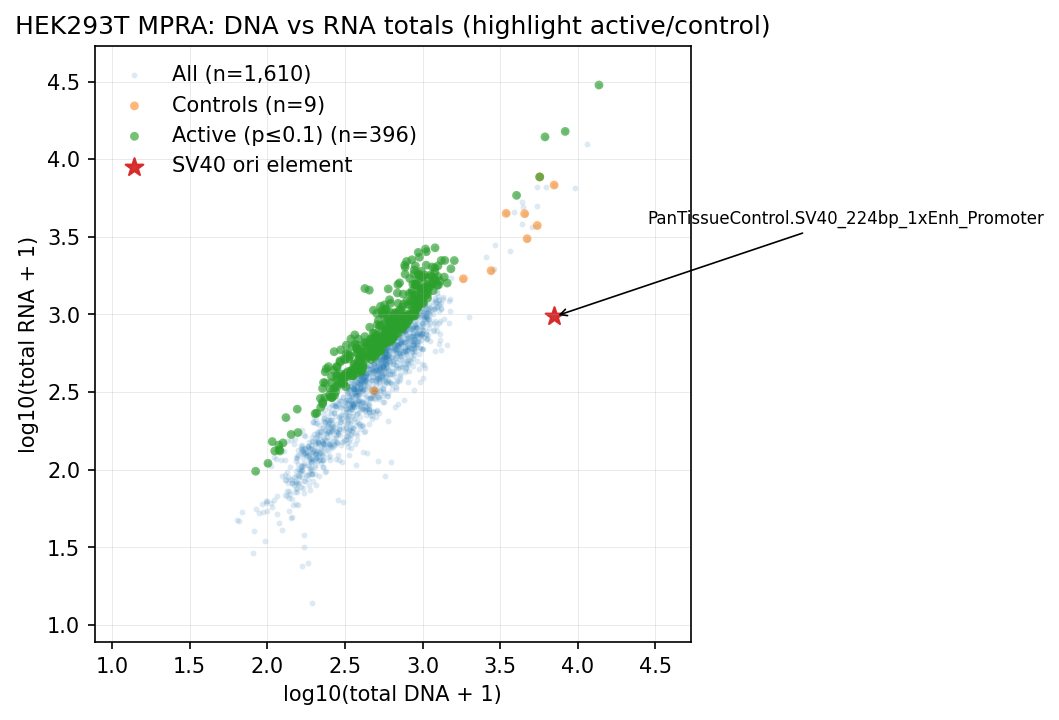

In [ ]:
#With controls
df_DNA <- read.csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref_withcontrols.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref_withcontrols.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Macrophage_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260120_MAD_THP1Macrophage.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2026-01-20 18:53:55.56814
Success: TRUE

Task duration:
    user   system  elapsed 
 555.126 1587.812 1528.450 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6301924 336.6   12103782 646.5 12103782 646.5
Vcells 12431647  94.9   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-20 18:28:27] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 20
Node: 5
Timestamp: 2026-01-20 19:06:11.506973
Success: TRUE

Task duration:
    user   system  elapsed 
 833.169 2318.395 2266.492 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6302629 336.6   12103782 646.5 12103782 646.5
Vcells 12440343  95.0   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-20 18:28:25] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 8
Node: 17
Timestamp: 2026

In [ ]:
#With controls NO SV40
df_DNA <- read.csv("read_counts_R1R2/THP1Macrophage_DNA_matched_barcodes_reshaped_altref_withcontrols_noSV40.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1Macrophage_RNA_matched_barcodes_reshaped_altref_withcontrols_noSV40.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Macrophage_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260120_MAD_THP1Macrophage_noSV40.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 9
Node: 16
Timestamp: 2026-01-24 18:58:39.708945
Success: TRUE

Task duration:
    user   system  elapsed 
 762.989 2085.568 2059.863 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6294573 336.2   12039294 643.0 12039294 643.0
Vcells 11852784  90.5   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-24 18:24:20] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 4
Node: 21
Timestamp: 2026-01-24 19:02:37.48098
Success: TRUE

Task duration:
    user   system  elapsed 
 802.146 2289.590 2297.778 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6296154 336.3   12039294 643.0 12039294 643.0
Vcells 11863318  90.6   21468864 163.8 21468864 163.8

Log messages:
INFO [2026-01-24 18:24:19] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 7
Node: 18
Timestamp: 2026

In [ ]:
python '/media/zihengc/T7/mpra3_lib_analysis/add_controls_to_altref.py' -w '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_reshaped_altref.csv' -l '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_enhancerid.csv' -o '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_DNA_matched_barcodes_reshaped_altref_withcontrol.csv' 

python '/media/zihengc/T7/mpra3_lib_analysis/add_controls_to_altref.py' -w '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_reshaped_altref.csv' -l '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_enhancerid.csv' -o '/media/zihengc/T7/mpra3_lib_analysis/read_counts_R1R2/BrainR1R2merged20260121_RNA_matched_barcodes_reshaped_altref_withcontrol.csv' 



# HMC3 All

In [ ]:

df_DNA <- read.csv("read_counts_R1R2/HMC3_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_barcodes_interaction.csv", header=TRUE,row.names=1)
df_DNA <- df_DNA[, !grepl("ZC23", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC23", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC23", rownames(annot_DNA)), ]
df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)


#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_HMC3.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-11-26 23:55:44.645387
Success: TRUE

Task duration:
   user  system elapsed 
 77.894   0.713  83.006 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6182741 330.2   11623467 620.8 10290760 549.6
Vcells 11954782  91.3   23095196 176.3 23094931 176.3

Log messages:
INFO [2024-11-26 23:54:21] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 20
Timestamp: 2024-11-26 23:55:50.66767
Success: TRUE

Task duration:
   user  system elapsed 
 84.376   0.936  89.620 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6183426 330.3   11623467 620.8 10290760 549.6
Vcells 11962891  91.3   23095196 176.3 23094931 176.3

Log messages:
INFO [2024-11-26 23:54:21] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 9
Node: 16
Timestamp: 2024-11-26 23:55

# HMC3 With Baseline

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/HMC3_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_barcodes_interaction.csv", header=TRUE,row.names=1)
df_DNA <- df_DNA[, !grepl("ZC23", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC23", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC23", rownames(annot_DNA)), ]
df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)


#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ Tissue
                            )
alpha <- getAlpha(obj, by.factor = "Tissue")
for (col_names in names(alpha)){   
    result <- testEmpirical(obj = obj,statistic = alpha[,col_names])
    row.names(result)<-row.names(alpha)
    write.csv(result, paste("enhancer_activities/MAD_OneTail_NoControl/20240823_MAD_",col_names,".csv",sep=""))}


Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-08-13 00:01:35.068063
Success: TRUE

Task duration:
   user  system elapsed 
122.448   0.707 130.084 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6170440 329.6   11607041 619.9  8190798 437.5
Vcells 11920832  91.0   23110480 176.4 19192055 146.5

Log messages:
INFO [2024-08-12 23:59:25] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 1
Node: 24
Timestamp: 2024-08-13 00:01:45.24344
Success: TRUE

Task duration:
   user  system elapsed 
132.251   0.726 140.828 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6171123 329.6   11607041 619.9  8190798 437.5
Vcells 11929336  91.1   23110480 176.4 19192055 146.5

Log messages:
INFO [2024-08-12 23:59:24] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 23
Node: 2
Timestamp: 2024-08-13 00:01

# THP1 Monocytes

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/THP1mono20240412_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1mono20240412_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1Monocyte20240412_barcodes.csv", header=TRUE,row.names=1)
df_DNA <- df_DNA[, !grepl("ZC37|ZC60", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC37|ZC60", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC37|ZC60", rownames(annot_DNA)), ]

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240729_MAD_THP1Monocyte.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 23
Node: 1
Timestamp: 2024-07-29 02:12:54
Success: TRUE

Task duration:
   user  system elapsed 
  7.907   0.936   9.765 

Memory used:
          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 5388129 287.8    8040154 429.4  7409332 395.8
Vcells 9436176  72.0   18729336 142.9 17802400 135.9

Log messages:
INFO [2024-07-29 02:12:44] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 4
Node: 20
Timestamp: 2024-07-29 02:12:55
Success: TRUE

Task duration:
   user  system elapsed 
  8.909   0.797  10.456 

Memory used:
          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 5403562 288.6    8040154 429.4  7409332 395.8
Vcells 9521909  72.7   18729336 142.9 17802400 135.9

Log messages:
INFO [2024-07-29 02:12:44] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 19
Timestamp: 2024-07-29 02:12:55
Success: TRUE



# THP1 Region Separate (archived)

In [ ]:
####20240812
df_DNA <- read.csv("read_counts_R1R2/THP1_LPSIFNG_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1_LPSIFNG_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1_LPSIFNG_barcodes.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)


#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240812_MAD_THP1_LPSIFNG.csv")

df_DNA <- read.csv("read_counts_R1R2/THP1_IFNG_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1_IFNG_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1_IFNG_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_THP1_IFNG.csv")

df_DNA <- read.csv("read_counts_R1R2/THP1_IFNB_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1_IFNB_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1_IFNB_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_THP1_IFNB.csv")

df_DNA <- read.csv("read_counts_R1R2/THP1_Naive_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/THP1_Naive_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_THP1_Naive_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_THP1_Naive.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2024-08-13 00:02:42.394557
Success: TRUE

Task duration:
   user  system elapsed 
 22.447   0.430  23.833 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6170317 329.6   11607041 619.9 10078030 538.3
Vcells 11264154  86.0   23110480 176.4 20805238 158.8

Log messages:
INFO [2024-08-13 00:02:18] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 20
Timestamp: 2024-08-13 00:02:43.707676
Success: TRUE

Task duration:
   user  system elapsed 
 23.984   0.403  25.478 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6172276 329.7   11607041 619.9 10078030 538.3
Vcells 11285752  86.2   23110480 176.4 20805238 158.8

Log messages:
INFO [2024-08-13 00:02:17] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 9
Node: 16
Timestamp: 2024-08-13 00:0

# HMC3 Region Separate (archived)

In [ ]:
df_DNA <- read.csv("read_counts_R1R2/HMC3_LPSIFNG_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_LPSIFNG_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_LPSIFNG_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_HMC3_LPSIFNG.csv")

df_DNA <- read.csv("read_counts_R1R2/HMC3_IFNB_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_IFNB_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_IFNB_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_HMC3_IFNB.csv")

df_DNA <- read.csv("read_counts_R1R2/HMC3_Naive_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_Naive_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_Naive_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240418_MAD_HMC3_Naive.csv")


df_DNA <- read.csv("read_counts_R1R2/HMC3_IFNG_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HMC3_IFNG_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HMC3_IFNG_barcodes.csv", header=TRUE,row.names=1)
df_DNA <- df_DNA[, !grepl("ZC23", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC23", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC23", rownames(annot_DNA)), ]
df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)


#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]
###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20240812_MAD_HMC3_IFNG.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 5
Node: 27
Timestamp: 2024-05-31 13:41:56.693536
Success: TRUE

Task duration:
   user  system elapsed 
  8.919   0.202   9.438 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6301974 336.6   12115555 647.1  8467851 452.3
Vcells 11458467  87.5   23194059 177.0 19937457 152.2

Log messages:
INFO [2024-05-31 13:41:47] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 20
Node: 12
Timestamp: 2024-05-31 13:41:57.468295
Success: TRUE

Task duration:
   user  system elapsed 
  9.624   0.195   9.900 

Memory used:
           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  6303485 336.7   12115555 647.1  8467851 452.3
Vcells 11475004  87.6   23194059 177.0 19937457 152.2

Log messages:
INFO [2024-05-31 13:41:47] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 2
Node: 30
Timestamp: 2024-05-31 13:

# Brain Region Separate (archived)

In [ ]:

################################################################################################################################################################################################
df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Striatum_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Striatum_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_Striatum_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_Brain_Striatum_Separate.csv")


df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Cortex_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Cortex_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_Cortex_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_Brain_Cortex_Separate.csv")


df_DNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Hippocampus_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/BrainR1R2merged20240404_Hippocampus_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_BrainR1R2merged20240404_Hippocampus_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20241126_MAD_Brain_Hippocampus_Separate.csv")

# HEK293T

In [ ]:

df_DNA <- read.csv("read_counts_R1R2/HEK293T_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("read_counts_R1R2/HEK293T_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
annot_DNA <-read.csv("annotation_barcodes/mpra3_annot_HEK293T_barcodes.csv", header=TRUE,row.names=1)
df_DNA <- df_DNA[, !grepl("ZC65|ZC66", colnames(df_DNA))]
df_RNA <- df_RNA[, !grepl("ZC65|ZC66", colnames(df_RNA))]
annot_DNA <- annot_DNA[!grepl("ZC65|ZC66", rownames(annot_DNA)), ]

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]
##############################################################
total_columns <- ncol(df_DNA)
selected_columns <- seq(from = 1, to = total_columns)[((seq(from = 1, to = total_columns) - 1) %% 32) < 15]
df_DNA <- df_DNA[, selected_columns]
df_RNA <- df_RNA[, selected_columns]
annot_DNA <- annot_DNA[selected_columns,]

###############################################################
obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )

#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   

obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)

write.csv(test_results,"20240716_MAD_HEK293T.csv")

Fitting model...

############### LOG OUTPUT ###############
Task: 23
Node: 1
Timestamp: 2024-07-16 13:44:31
Success: TRUE

Task duration:
   user  system elapsed 
 21.435   0.379  23.378 

Memory used:
          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 5390477 287.9    8459960 451.9  8439507 450.8
Vcells 9519791  72.7   18606928 142.0 18606643 142.0

Log messages:
INFO [2024-07-16 13:44:07] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 5
Node: 19
Timestamp: 2024-07-16 13:44:32
Success: TRUE

Task duration:
   user  system elapsed 
 23.312   0.258  24.704 

Memory used:
          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 5391585 288.0    8459960 451.9  8439507 450.8
Vcells 9528094  72.7   18606928 142.0 18606643 142.0

Log messages:
INFO [2024-07-16 13:44:07] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 17
Node: 7
Timestamp: 2024-07-16 13:44:33
Success: TRUE



# Neuron


In [2]:
df_DNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/ad_mpra_chen/annotation_barcodes/mpra3_annot_NeuronPseudobarcodes_altref_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  #control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260625_MAD_Neuron_Pseudobarcode.csv")


Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2026-06-27 16:18:43.826689
Success: TRUE

Task duration:
   user  system elapsed 
  2.230   0.443  10.017 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6225730 332.5   11452545 611.7         NA  8110306 433.2
Vcells 11205172  85.5   21468864 163.8      32768 14100460 107.6

Log messages:
INFO [2026-06-27 16:18:33] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 7
Node: 18
Timestamp: 2026-06-27 16:18:45.203165
Success: TRUE

Task duration:
   user  system elapsed 
  2.514   0.464  11.275 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6242120 333.4   11452545 611.7         NA  8110306 433.2
Vcells 11293008  86.2   21468864 163.8      32768 14100460 107.6

Log messages:
INFO [2026-06-27 16:18:33] loading futile.logger package

stderr and stdout:


############### LOG 

In [10]:
df_DNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_DNA_matched_barcodes_reshaped_altref_controls.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_RNA_matched_barcodes_reshaped_altref_controls.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/ad_mpra_chen/annotation_barcodes/mpra3_annot_NeuronPseudobarcodes_altref_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260625_MAD_Neuron_Pseudobarcode_control_R1R2.csv")


Fitting model...

############### LOG OUTPUT ###############
Task: 16
Node: 9
Timestamp: 2026-06-28 00:24:35.826265
Success: TRUE

Task duration:
   user  system elapsed 
  0.045   0.035   0.183 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6233519 333.0   11452545 611.7         NA  9629659 514.3
Vcells 11152177  85.1   21468864 163.8      32768 19634531 149.8

Log messages:
INFO [2026-06-28 00:24:35] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 7
Node: 18
Timestamp: 2026-06-28 00:24:36.774433
Success: TRUE

Task duration:
   user  system elapsed 
  0.082   0.068   0.402 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6234021 333.0   11452545 611.7         NA  9629659 514.3
Vcells 11154408  85.2   21468864 163.8      32768 19634531 149.8

Log messages:
INFO [2026-06-28 00:24:35] loading futile.logger package

stderr and stdout:


############### LOG 

In [ ]:
df_DNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/Neuron_DNA_matched_barcodes_reshaped_altref_controls.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/Neuron_RNA_matched_barcodes_reshaped_altref_controls.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/ad_mpra_chen/annotation_barcodes/mpra3_annot_NeuronPseudobarcodes_altref_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260625_MAD_Neuron_control_R1R2.csv")


ERROR: Error in validObject(.Object): invalid class "MpraObject" object: 1: DNA observations and annotations don't match
invalid class "MpraObject" object: 2: RNA observations and annotations don't match


In [10]:
annot_DNA

,Tissue,Delivery,Date,Animal,Sex,Test,Function,Parent,Neuron,Replicate,RT_reaction,Barcode_number,Barcode_Allele,Allele_String,Test_Allele,Animal_Allele,Tissue_Allele
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_1,iPSCNeuron,MPRA,NA,Rep1,NA,Rep1_iPSCNeuron_ZC130_R,Neuron,NeuronPseudobarcodes,1,1,Rep1_iPSCNeuron_ZC130_R,1,1_ALT,ALT,Rep1_iPSCNeuron_ZC130_R_ALT,Rep1_ALT,iPSCNeuron_ALT
Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_2,iPSCNeuron,MPRA,NA,Rep1,NA,Rep1_iPSCNeuron_ZC130_R,Neuron,NeuronPseudobarcodes,1,1,Rep1_iPSCNeuron_ZC130_R,2,2_ALT,ALT,Rep1_iPSCNeuron_ZC130_R_ALT,Rep1_ALT,iPSCNeuron_ALT
Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_3,iPSCNeuron,MPRA,NA,Rep1,NA,Rep1_iPSCNeuron_ZC130_R,Neuron,NeuronPseudobarcodes,1,1,Rep1_iPSCNeuron_ZC130_R,3,3_ALT,ALT,Rep1_iPSCNeuron_ZC130_R_ALT,Rep1_ALT,iPSCNeuron_ALT
Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_4,iPSCNeuron,MPRA,NA,Rep1,NA,Rep1_iPSCNeuron_ZC130_R,Neuron,NeuronPseudobarcodes,1,1,Rep1_iPSCNeuron_ZC130_R,4,4_ALT,ALT,Rep1_iPSCNeuron_ZC130_R_ALT,Rep1_ALT,iPSCNeuron_ALT
Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_5,iPSCNeuron,MPRA,NA,Rep1,NA,Rep1_iPSCNeuron_ZC130_R,Neuron,NeuronPseudobarcodes,1,1,Rep1_iPSCNeuron_ZC130_R,5,5_ALT,ALT,Rep1_iPSCNeuron_ZC130_R_ALT,Rep1_ALT,iPSCNeuron_ALT
Rep2_iPSCNeuron_ZC131_R_ALT_Barcode_1,iPSCNeuron,MPRA,NA,Rep2,NA,Rep2_iPSCNeuron_ZC131_R,Neuron,NeuronPseudobarcodes,1,2,Rep2_iPSCNeuron_ZC131_R,1,1_ALT,ALT,Rep2_iPSCNeuron_ZC131_R_ALT,Rep2_ALT,iPSCNeuron_ALT
Rep2_iPSCNeuron_ZC131_R_ALT_Barcode_2,iPSCNeuron,MPRA,NA,Rep2,NA,Rep2_iPSCNeuron_ZC131_R,Neuron,NeuronPseudobarcodes,1,2,Rep2_iPSCNeuron_ZC131_R,2,2_ALT,ALT,Rep2_iPSCNeuron_ZC131_R_ALT,Rep2_ALT,iPSCNeuron_ALT
Rep2_iPSCNeuron_ZC131_R_ALT_Barcode_3,iPSCNeuron,MPRA,NA,Rep2,NA,Rep2_iPSCNeuron_ZC131_R,Neuron,NeuronPseudobarcodes,1,2,Rep2_iPSCNeuron_ZC131_R,3,3_ALT,ALT,Rep2_iPSCNeuron_ZC131_R_ALT,Rep2_ALT,iPSCNeuron_ALT
Rep2_iPSCNeuron_ZC131_R_ALT_Barcode_4,iPSCNeuron,MPRA,NA,Rep2,NA,Rep2_iPSCNeuron_ZC131_R,Neuron,NeuronPseudobarcodes,1,2,Rep2_iPSCNeuron_ZC131_R,4,4_ALT,ALT,Rep2_iPSCNeuron_ZC131_R_ALT,Rep2_ALT,iPSCNeuron_ALT


In [8]:
df_DNA

,Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_1,Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_2,Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_3,Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_4,Rep1_iPSCNeuron_ZC130_R_ALT_Barcode_5,Rep1_iPSCNeuron_ZC130_R_REF_Barcode_1,Rep1_iPSCNeuron_ZC130_R_REF_Barcode_2,Rep1_iPSCNeuron_ZC130_R_REF_Barcode_3,Rep1_iPSCNeuron_ZC130_R_REF_Barcode_4,Rep1_iPSCNeuron_ZC130_R_REF_Barcode_5,...,Rep4_iPSCNeuron_ZC133_R_ALT_Barcode_1,Rep4_iPSCNeuron_ZC133_R_ALT_Barcode_2,Rep4_iPSCNeuron_ZC133_R_ALT_Barcode_3,Rep4_iPSCNeuron_ZC133_R_ALT_Barcode_4,Rep4_iPSCNeuron_ZC133_R_ALT_Barcode_5,Rep4_iPSCNeuron_ZC133_R_REF_Barcode_1,Rep4_iPSCNeuron_ZC133_R_REF_Barcode_2,Rep4_iPSCNeuron_ZC133_R_REF_Barcode_3,Rep4_iPSCNeuron_ZC133_R_REF_Barcode_4,Rep4_iPSCNeuron_ZC133_R_REF_Barcode_5
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,799,2605,1971,2451,2007,1910,2782,2365,2193,2883,...,862,2514,2110,2432,2104,1869,2656,2241,2143,2914
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,5036,5066,3898,4437,4958,2709,3020,3429,3505,5164,...,3334,4718,4015,3961,5026,2479,3171,3193,3531,5023
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,1162,772,1474,1390,1483,1424,1486,1043,1138,1189,...,994,732,1331,1228,1320,1288,1168,951,1834,984
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,2536,2008,3452,2307,3112,2097,2770,2817,2673,2980,...,2373,1908,3166,2339,2935,1929,2870,2821,2605,2684
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,543,922,752,1112,1304,888,963,909,1299,1329,...,591,879,649,1101,1315,986,1064,870,1466,1481
alt:cg07571519:SNPCENTER:chr10:73472315:C:G:73472202:73472428:73472315,2970,2613,2594,1933,2380,1898,2386,2685,2854,2811,...,2626,2453,2339,1845,2256,1791,2372,2775,2360,2702
alt:cg14761246:SNPCENTER:chr3:182968758:C:G:182968645:182968871:182968758,1710,2515,3172,2791,3566,2927,4078,2617,3566,3106,...,1843,2733,3126,2710,3358,2860,3681,2593,3370,3113
alt:cg20618448:SNPCENTER:chr19:49962324:C:G:49962211:49962437:49962324,2430,2430,2821,2458,3293,2902,2965,3607,3884,4205,...,2359,2336,2773,2531,3403,2985,3149,3379,3899,4349
alt:cg20648333:SNPCENTER:chr10:72298745:C:G:72298632:72298858:72298745,3388,2699,3324,2557,2675,2401,3036,2826,2970,3020,...,3365,3006,3659,2934,2972,2448,3387,3091,3205,3118
alt:cg22090150:SNPCENTER:chr17:4098227:C:G:4098114:4098340:4098227,964,1461,1424,1268,1119,939,1201,562,1315,1211,...,833,1163,1137,1040,928,733,1102,445,1022,987


In [ ]:


df_DNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronPseudobarcodes_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/ad_mpra_chen/annotation_barcodes/mpra3_annot_NeuronPseudobarcodes_altref_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260625_MAD_Neuron_pseudobarcode_all_R1R2.csv")


Fitting model...

############### LOG OUTPUT ###############
Task: 24
Node: 1
Timestamp: 2026-06-30 01:23:49.229667
Success: TRUE

Task duration:
   user  system elapsed 
  2.401   1.575  18.808 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6238381 333.2   11606267 619.9         NA 10675701 570.2
Vcells 11201253  85.5   18705754 142.8      32768 18705489 142.8

Log messages:
INFO [2026-06-30 01:23:30] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 11
Node: 14
Timestamp: 2026-06-30 01:23:50.586709
Success: TRUE

Task duration:
   user  system elapsed 
  2.671   1.677  20.177 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6254744 334.1   11606267 619.9         NA 10675701 570.2
Vcells 11289044  86.2   18705754 142.8      32768 18705489 142.8

Log messages:
INFO [2026-06-30 01:23:29] loading futile.logger package

stderr and stdout:


############### LOG

In [12]:
df_DNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronControlPseudobarcodes10_DNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)
df_RNA <- read.csv("/Volumes/T7/ad_mpra_chen/outputs/read_counts_R1R2/NeuronControlPseudobarcodes10_RNA_matched_barcodes_reshaped_altref.csv", header=TRUE,row.names=1)

df_DNA<-as.matrix(df_DNA)
df_RNA<-as.matrix(df_RNA)
annot_DNA <-read.csv("/Volumes/T7/ad_mpra_chen/annotation_barcodes/mpra3_annot_NeuronControlPseudobarcodes10_altref_barcodes.csv", header=TRUE,row.names=1)

#Format the columns as factor that is recognized by MPRAnalyze
for (i in colnames(annot_DNA)){
    annot_DNA[i] <- as.factor(annot_DNA[,i])
}
#Read negative controls
negative <- read.csv('indexing/mpra3_negatives.csv' , sep="\t",header=FALSE)
control <- as.character(negative$V1)#V1 is the sequence_ID

annot_DNA <- annot_DNA [!grepl("REF", rownames(annot_DNA )), ]

obj <- MpraObject(dnaCounts=df_DNA,
                  rnaCounts=df_RNA,
                  colAnnot=annot_DNA,
                  control=control,
                  BPPARAM = bpparam
                  )
#Comparative analysisl; Tissue only
obj <- estimateDepthFactors(obj, lib.factor = c("Test"), which.lib = "both",depth.estimator = "uq")   
obj <- analyzeQuantification(
                            obj = obj, 
                            dnaDesign = ~ Barcode_Allele+Test, 
                            rnaDesign = ~ 1
                            )
test_results <- testEmpirical(obj = obj,twoSided = FALSE)
write.csv(test_results,"20260625_MAD_Neuron_10pseudobarcode_control_R1R2.csv")


Fitting model...

############### LOG OUTPUT ###############
Task: 16
Node: 9
Timestamp: 2026-06-28 00:24:50.860146
Success: TRUE

Task duration:
   user  system elapsed 
  0.061   0.029   0.107 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6233661 333.0   11452545 611.7         NA  9629659 514.3
Vcells 11154036  85.1   21468864 163.8      32768 19634531 149.8

Log messages:
INFO [2026-06-28 00:24:50] loading futile.logger package

stderr and stdout:


############### LOG OUTPUT ###############
Task: 4
Node: 21
Timestamp: 2026-06-28 00:24:51.124627
Success: TRUE

Task duration:
   user  system elapsed 
  0.120   0.054   0.258 

Memory used:
           used  (Mb) gc trigger  (Mb) limit (Mb) max used  (Mb)
Ncells  6234163 333.0   11452545 611.7         NA  9629659 514.3
Vcells 11156267  85.2   21468864 163.8      32768 19634531 149.8

Log messages:
INFO [2026-06-28 00:24:50] loading futile.logger package

stderr and stdout:


############### LOG 